# HMM Regime Detection — Development Notebook

**Goal:** Fit a Gaussian Hidden Markov Model on S&P 500 features to detect 3 market regimes (low / medium / high volatility).

**Architecture:**
```
YFinance → [log return, rolling vol, MA ratio] → HMM → regime (0,1,2)
                                                          ↓
                                         RL Agent (low vol | med vol | high vol)
```

**Observation features for HMM:**
1. Daily log return
2. 20-day rolling volatility
3. MA(20)/MA(60) ratio (short vs long-term trend)

**Sections:**
1. Data download & feature engineering
2. Fit Gaussian HMM (3 states)
3. Visualize regimes on price chart
4. Analyze transition matrix & stationary distribution
5. Compare HMM vs simple threshold approach
6. Out-of-sample regime prediction
7. Interface for RL agents

## 0. Imports & Setup

In [1]:
import importlib
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

# Our modules
import src.hmm as hmm_module
importlib.reload(hmm_module)
from src.hmm import RegimeDetector, compute_hmm_features

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (15, 6)
plt.rcParams['font.size'] = 12

print('Imports OK')

Imports OK


## 1. Download Data & Compute Features

In [2]:
# Download S&P 500 data (long history for robust HMM training)
START = '2006-01-01'
END   = '2025-01-01'

raw = yf.download('^GSPC', start=START, end=END)

# Handle MultiIndex columns from newer yfinance versions
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

sp500 = raw['Close'].copy()
sp500.name = 'SP500'

print(f'S&P 500 data: {sp500.index[0].date()} to {sp500.index[-1].date()}, {len(sp500)} trading days')
sp500.tail()

[*********************100%***********************]  1 of 1 completed

S&P 500 data: 2006-01-03 to 2024-12-31, 4781 trading days


Date
2024-12-24    6040.040039
2024-12-26    6037.589844
2024-12-27    5970.839844
2024-12-30    5906.939941
2024-12-31    5881.629883
Name: SP500, dtype: float64

In [3]:
# Compute HMM observation features
features = compute_hmm_features(sp500, vol_window=20, ma_short=20, ma_long=60)

print(f'Features shape: {features.shape}')
print(f'Date range: {features.index[0].date()} to {features.index[-1].date()}')
print()
features.describe().round(6)

Features shape: (4722, 3)
Date range: 2006-03-29 to 2024-12-31



,daily_log_return,rolling_vol,ma_ratio
count,4722.000000,4722.000000,4722.000000
mean,0.000321,0.010176,1.006634
std,0.012388,0.007203,0.030141
min,-0.127652,0.002069,0.829275
25%,-0.004103,0.005915,0.995456
50%,0.000715,0.008404,1.012224
75%,0.005803,0.012116,1.025123
max,0.109572,0.061669,1.083015


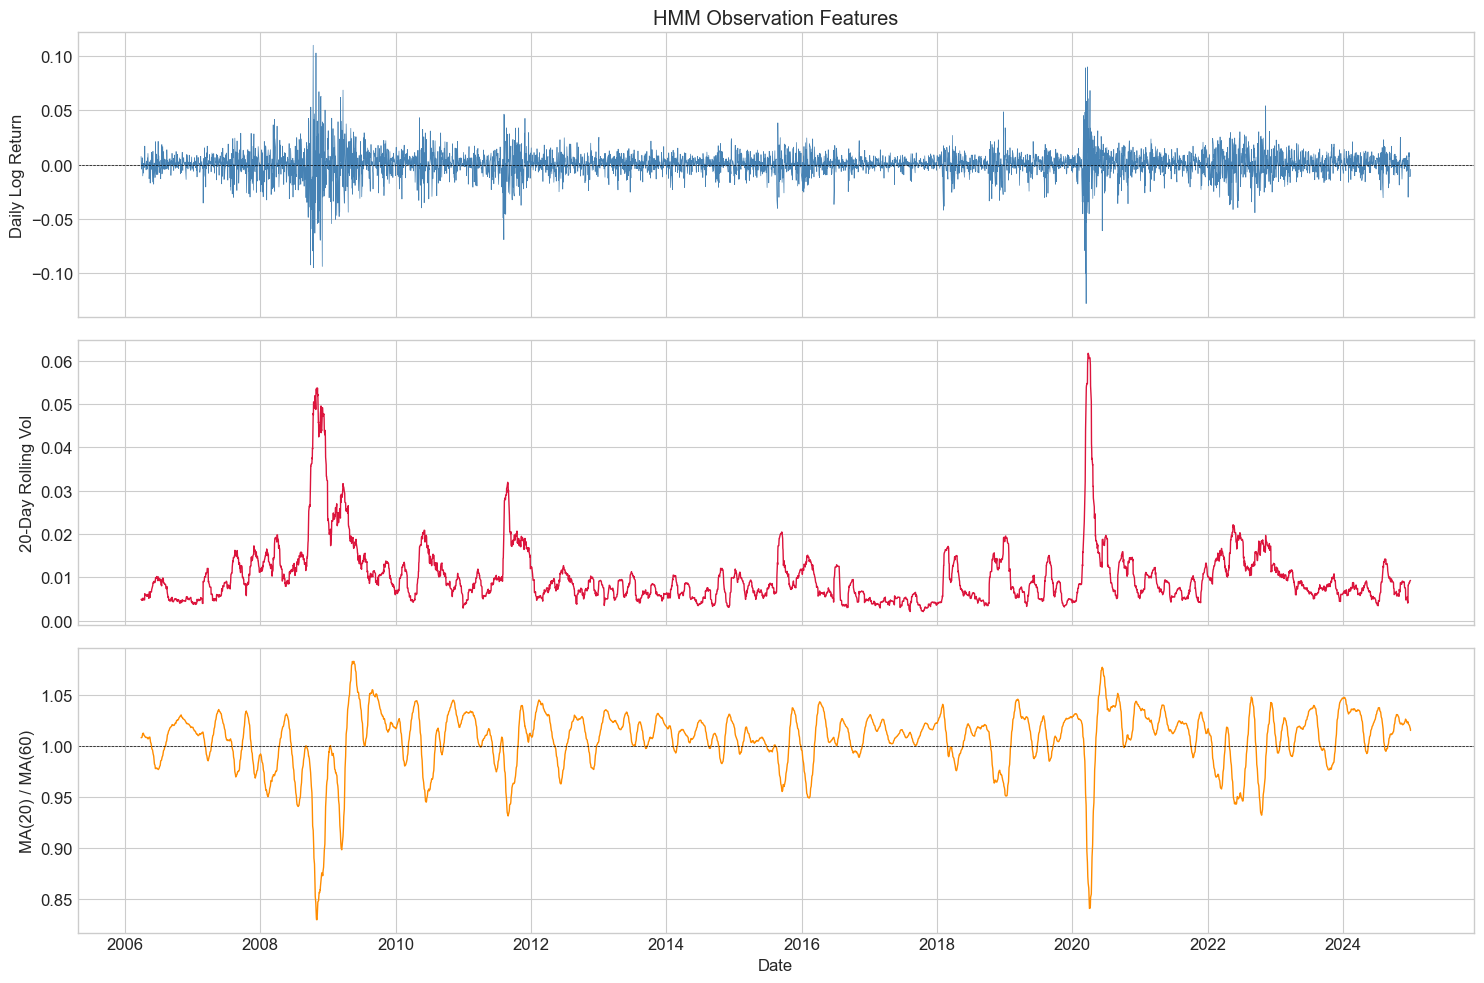

In [4]:
# Visualize the raw features
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

axes[0].plot(features.index, features['daily_log_return'], lw=0.5, color='steelblue')
axes[0].set_ylabel('Daily Log Return')
axes[0].set_title('HMM Observation Features')
axes[0].axhline(0, color='black', lw=0.5, ls='--')

axes[1].plot(features.index, features['rolling_vol'], lw=1, color='crimson')
axes[1].set_ylabel('20-Day Rolling Vol')

axes[2].plot(features.index, features['ma_ratio'], lw=1, color='darkorange')
axes[2].set_ylabel('MA(20) / MA(60)')
axes[2].axhline(1.0, color='black', lw=0.5, ls='--')
axes[2].set_xlabel('Date')

plt.tight_layout()
plt.show()

## 2. Train/Test Split & Fit HMM

In [5]:
# Split: train on 2006-2019, test on 2020-2024
# (test includes COVID crash, 2022 bear market, 2023-24 recovery)
TRAIN_END = '2020-01-01'

train_features = features.loc[:TRAIN_END]
test_features  = features.loc[TRAIN_END:]

print(f'Train: {train_features.index[0].date()} to {train_features.index[-1].date()} ({len(train_features)} days)')
print(f'Test:  {test_features.index[0].date()} to {test_features.index[-1].date()} ({len(test_features)} days)')

Train: 2006-03-29 to 2019-12-31 (3464 days)
Test:  2020-01-02 to 2024-12-31 (1258 days)


In [6]:
# Fit the Gaussian HMM with 3 regimes
detector = RegimeDetector(n_regimes=3, covariance_type='full', n_iter=200, random_state=42)
detector.fit(train_features)

print('HMM fitted successfully!')
print(f'Log-likelihood (train): {detector.score(train_features):.2f}')
print(f'Log-likelihood (test):  {detector.score(test_features):.2f}')

Model is not converging.  Current: 36187.56625402952 is not greater than 36187.74063261984. Delta is -0.17437859031633707


HMM fitted successfully!
Log-likelihood (train): 36187.22
Log-likelihood (test):  12530.43


In [7]:
# Predict regimes for both train and test
train_regimes = detector.predict(train_features)
test_regimes  = detector.predict(test_features)

# Combine for full history
all_regimes = pd.concat([train_regimes, test_regimes])

print('Regime distribution (full):')
regime_names = {0: 'Low Vol', 1: 'Med Vol', 2: 'High Vol'}
for r in [0, 1, 2]:
    pct = (all_regimes == r).mean() * 100
    print(f'  Regime {r} ({regime_names[r]}): {pct:.1f}%')

print(f'\nTest period regime distribution:')
for r in [0, 1, 2]:
    pct = (test_regimes == r).mean() * 100
    print(f'  Regime {r} ({regime_names[r]}): {pct:.1f}%')

Regime distribution (full):
  Regime 0 (Low Vol): 57.2%
  Regime 1 (Med Vol): 33.2%
  Regime 2 (High Vol): 9.7%

Test period regime distribution:
  Regime 0 (Low Vol): 55.7%
  Regime 1 (Med Vol): 30.9%
  Regime 2 (High Vol): 13.4%


## 3. Visualize Regimes on Price Chart

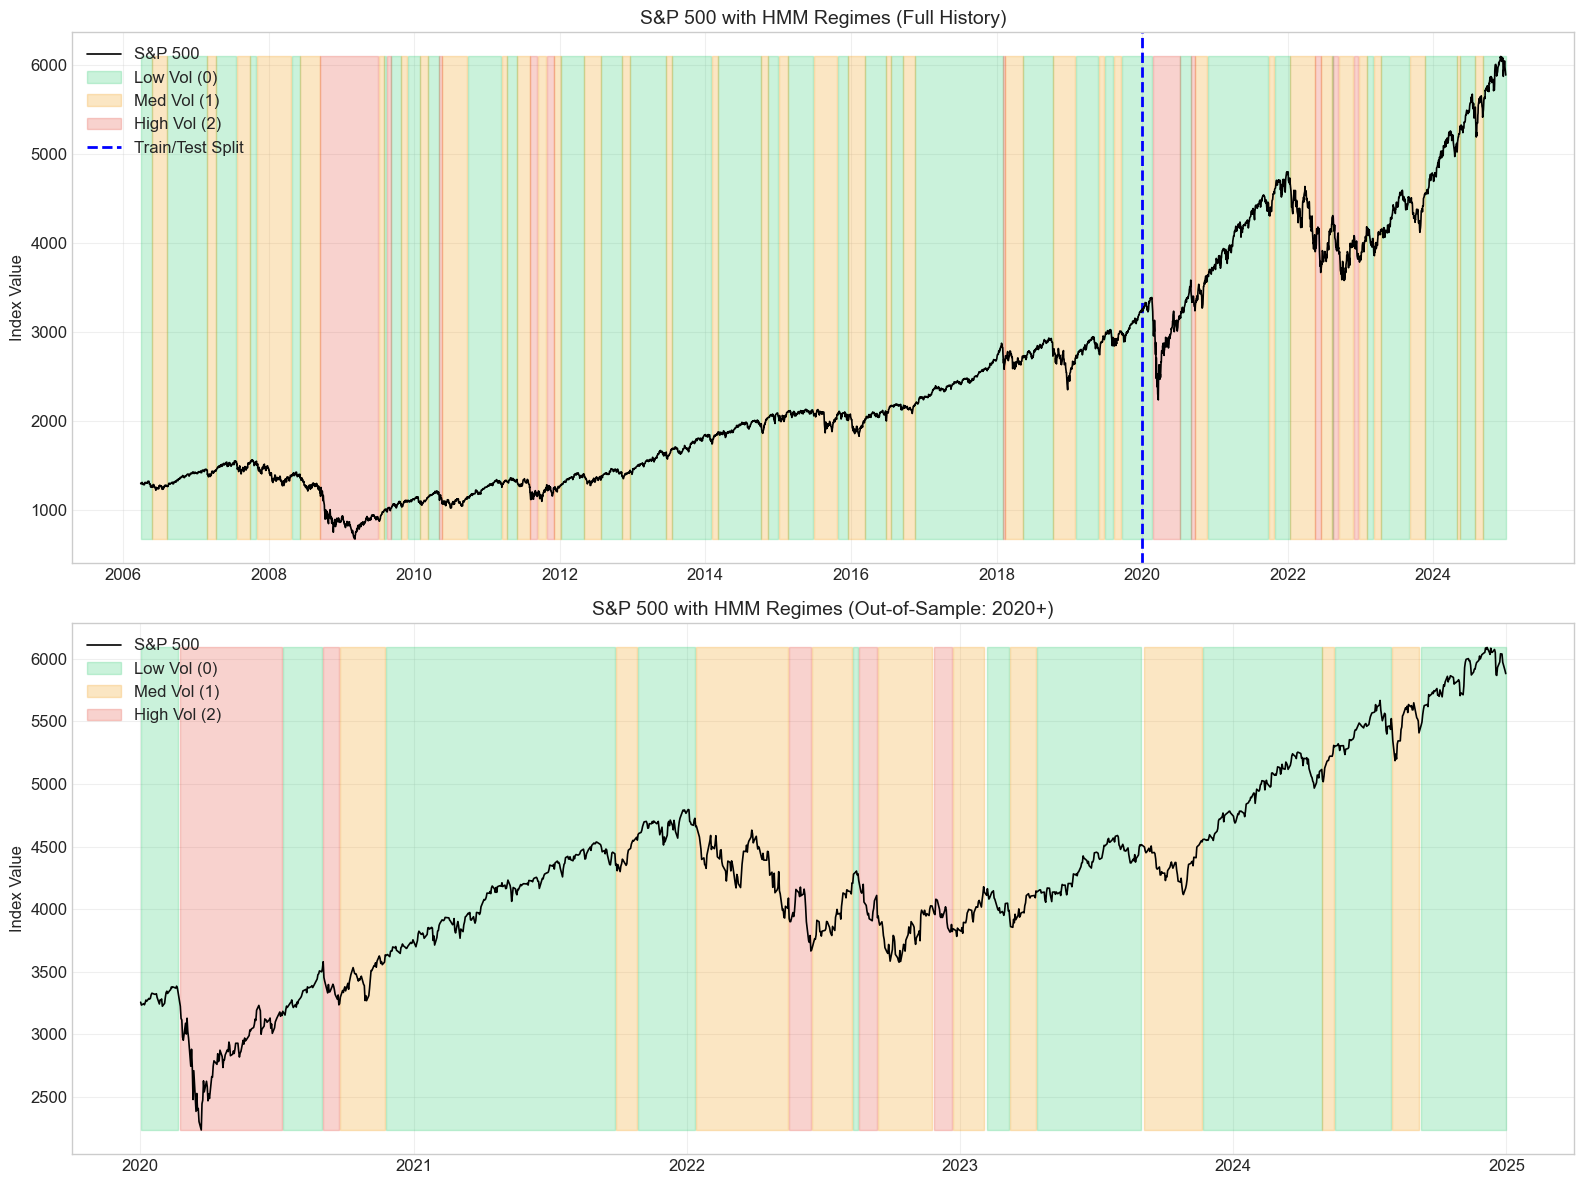

In [8]:
def plot_regimes(prices, regimes, title='S&P 500 with HMM Regimes', ax=None):
    """Plot price chart with colored regime backgrounds."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(16, 7))
    
    # Align prices to regime dates
    common = prices.index.intersection(regimes.index)
    p = prices.loc[common]
    r = regimes.loc[common]
    
    ax.plot(p.index, p.values, color='black', lw=1.2, label='S&P 500', zorder=3)
    
    colors = {0: '#2ecc71', 1: '#f39c12', 2: '#e74c3c'}
    labels = {0: 'Low Vol (0)', 1: 'Med Vol (1)', 2: 'High Vol (2)'}
    
    for regime in [0, 1, 2]:
        mask = (r == regime)
        ax.fill_between(p.index, p.min(), p.max(),
                       where=mask, color=colors[regime], alpha=0.25, label=labels[regime])
    
    ax.set_title(title, fontsize=14)
    ax.set_ylabel('Index Value')
    ax.legend(loc='upper left')
    ax.grid(alpha=0.3)
    return ax


# Full history
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

plot_regimes(sp500, all_regimes, title='S&P 500 with HMM Regimes (Full History)', ax=axes[0])
axes[0].axvline(pd.Timestamp(TRAIN_END), color='blue', ls='--', lw=2, label='Train/Test Split')
axes[0].legend(loc='upper left')

# Test period zoom
plot_regimes(sp500.loc[TRAIN_END:], test_regimes, 
             title='S&P 500 with HMM Regimes (Out-of-Sample: 2020+)', ax=axes[1])

plt.tight_layout()
plt.show()

## 4. Transition Matrix & Stationary Distribution

In [9]:
# Transition probability matrix
print('Transition Matrix: T[i,j] = P(regime j tomorrow | regime i today)')
print('='*60)
T = detector.transition_matrix
display(T.round(4))

print()
print('Interpretation:')
for i, row_label in enumerate(T.index):
    staying = T.iloc[i, i]
    print(f'  {row_label}: {staying:.1%} chance of staying in same regime')

Transition Matrix: T[i,j] = P(regime j tomorrow | regime i today)


,Low Vol,Med Vol,High Vol
Low Vol,0.9867,0.0118,0.0015
Med Vol,0.0221,0.9752,0.0026
High Vol,0.0044,0.0167,0.9789



Interpretation:
  Low Vol: 98.7% chance of staying in same regime
  Med Vol: 97.5% chance of staying in same regime
  High Vol: 97.9% chance of staying in same regime


In [11]:
# Stationary distribution
print('Stationary Distribution (long-run time fractions):')
print('='*50)
pi = detector.stationary_distribution
for label, prob in pi.items():
    print(f'  {label}: {prob:.1%}')

Stationary Distribution (long-run time fractions):
  Low Vol: 58.2%
  Med Vol: 33.4%
  High Vol: 8.4%


In [12]:
# Regime means (what each state "looks like" on average)
print('Regime Mean Feature Values:')
print('='*60)
display(detector.regime_means.round(6))

print()
print('Key observations:')
means = detector.regime_means
print(f'  Low Vol:  return={means.loc["Low Vol", "daily_log_return"]:.4%}, vol={means.loc["Low Vol", "rolling_vol"]:.6f}, MA ratio={means.loc["Low Vol", "ma_ratio"]:.4f}')
print(f'  Med Vol:  return={means.loc["Med Vol", "daily_log_return"]:.4%}, vol={means.loc["Med Vol", "rolling_vol"]:.6f}, MA ratio={means.loc["Med Vol", "ma_ratio"]:.4f}')
print(f'  High Vol: return={means.loc["High Vol", "daily_log_return"]:.4%}, vol={means.loc["High Vol", "rolling_vol"]:.6f}, MA ratio={means.loc["High Vol", "ma_ratio"]:.4f}')

Regime Mean Feature Values:


,daily_log_return,rolling_vol,ma_ratio
Low Vol,0.000646,0.006180,1.019309
Med Vol,0.000122,0.012174,0.986907
High Vol,-0.001811,0.025943,0.980627



Key observations:
  Low Vol:  return=0.0646%, vol=0.006180, MA ratio=1.0193
  Med Vol:  return=0.0122%, vol=0.012174, MA ratio=0.9869
  High Vol: return=-0.1811%, vol=0.025943, MA ratio=0.9806


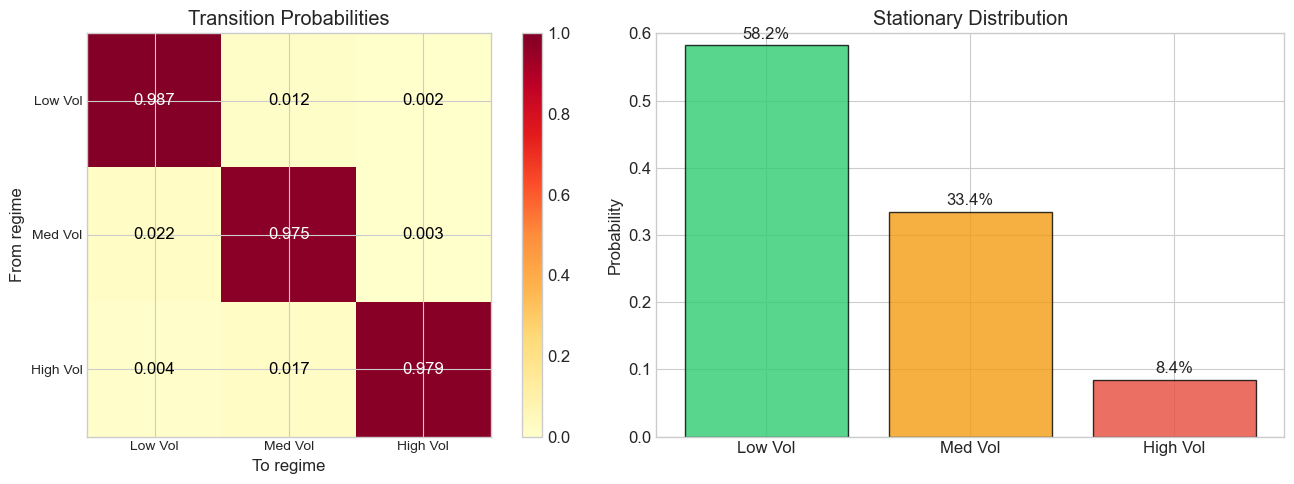

In [13]:
# Heatmap of transition matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Transition matrix heatmap
ax = axes[0]
im = ax.imshow(T.values, cmap='YlOrRd', vmin=0, vmax=1)
ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(T.columns, fontsize=10)
ax.set_yticklabels(T.index, fontsize=10)
ax.set_xlabel('To regime')
ax.set_ylabel('From regime')
ax.set_title('Transition Probabilities')

# Annotate cells
for i in range(3):
    for j in range(3):
        color = 'white' if T.values[i,j] > 0.5 else 'black'
        ax.text(j, i, f'{T.values[i,j]:.3f}', ha='center', va='center', color=color, fontsize=12)

plt.colorbar(im, ax=ax)

# Stationary distribution bar chart
ax = axes[1]
colors = ['#2ecc71', '#f39c12', '#e74c3c']
bars = ax.bar(pi.index, pi.values, color=colors, edgecolor='black', alpha=0.8)
ax.set_ylabel('Probability')
ax.set_title('Stationary Distribution')
ax.set_ylim(0, 0.6)

for bar, val in zip(bars, pi.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.1%}', ha='center', fontsize=12)

plt.tight_layout()
plt.show()

## 5. Compare HMM vs Threshold-Based Approach

The existing `regime_detection.ipynb` uses percentile thresholds on rolling vol.
Let's compare that with the HMM approach.

In [14]:
# Threshold-based regime (same as regime_detection.ipynb)
rolling_vol = features['rolling_vol']

# Use expanding quantiles (no lookahead) for fair comparison
low_thresh = rolling_vol.expanding(min_periods=252).quantile(0.33)
high_thresh = rolling_vol.expanding(min_periods=252).quantile(0.67)

conditions = [
    rolling_vol <= low_thresh,
    (rolling_vol > low_thresh) & (rolling_vol <= high_thresh),
    rolling_vol > high_thresh
]
threshold_regimes = pd.Series(
    np.select(conditions, [0, 1, 2], default=np.nan),
    index=features.index,
    name='regime_threshold'
).dropna().astype(int)

# Agreement rate
common = all_regimes.index.intersection(threshold_regimes.index)
agreement = (all_regimes.loc[common] == threshold_regimes.loc[common]).mean()
print(f'HMM vs Threshold agreement: {agreement:.1%}')

HMM vs Threshold agreement: 56.7%


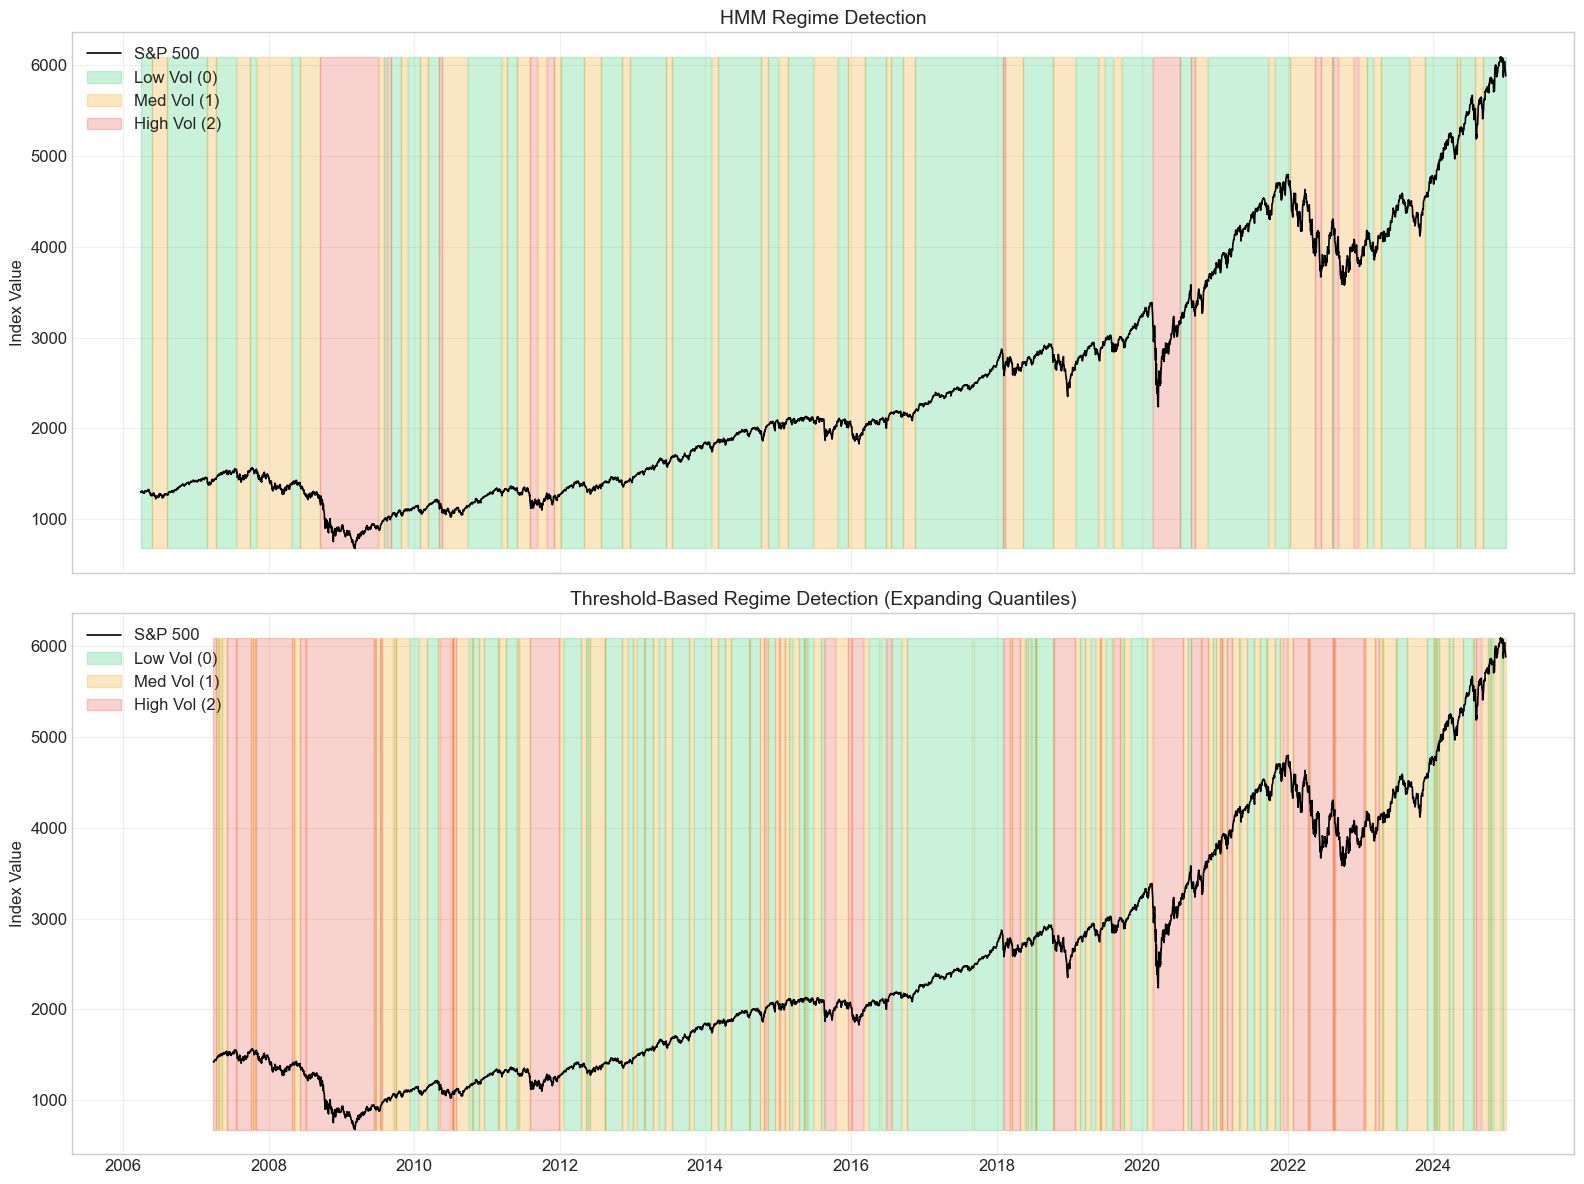

In [15]:
# Side-by-side comparison
fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

plot_regimes(sp500, all_regimes, title='HMM Regime Detection', ax=axes[0])
plot_regimes(sp500, threshold_regimes, title='Threshold-Based Regime Detection (Expanding Quantiles)', ax=axes[1])

plt.tight_layout()
plt.show()

In [16]:
# Disagreement analysis: where do HMM and threshold differ?
disagreement = all_regimes.loc[common] != threshold_regimes.loc[common]

print(f'Total disagreements: {disagreement.sum()} / {len(common)} days ({disagreement.mean():.1%})')
print()

# Confusion matrix
from sklearn.metrics import confusion_matrix, classification_report

print('Confusion Matrix (rows=HMM, cols=Threshold):')
cm = confusion_matrix(all_regimes.loc[common], threshold_regimes.loc[common])
cm_df = pd.DataFrame(cm, 
                      index=['HMM-Low', 'HMM-Med', 'HMM-High'],
                      columns=['Thresh-Low', 'Thresh-Med', 'Thresh-High'])
display(cm_df)

Total disagreements: 1937 / 4471 days (43.3%)

Confusion Matrix (rows=HMM, cols=Threshold):


,Thresh-Low,Thresh-Med,Thresh-High
HMM-Low,1551,872,100
HMM-Med,71,563,857
HMM-High,1,36,420


## 6. Regime Characteristics Analysis

In [17]:
# Analyze returns and volatility within each regime
analysis = pd.DataFrame({
    'regime': all_regimes,
    'log_return': features.loc[all_regimes.index, 'daily_log_return'],
    'rolling_vol': features.loc[all_regimes.index, 'rolling_vol'],
    'ma_ratio': features.loc[all_regimes.index, 'ma_ratio'],
})

print('Regime Statistics:')
print('='*70)
for r in [0, 1, 2]:
    sub = analysis[analysis['regime'] == r]
    ann_return = sub['log_return'].mean() * 252
    ann_vol = sub['log_return'].std() * np.sqrt(252)
    sharpe = ann_return / ann_vol if ann_vol > 0 else 0
    avg_rolling_vol = sub['rolling_vol'].mean()
    avg_ma_ratio = sub['ma_ratio'].mean()
    n_days = len(sub)
    
    print(f'\n  Regime {r} ({regime_names[r]}) — {n_days} days ({n_days/len(analysis)*100:.1f}%)')
    print(f'    Annualized Return: {ann_return:.2%}')
    print(f'    Annualized Vol:    {ann_vol:.2%}')
    print(f'    Sharpe Ratio:      {sharpe:.2f}')
    print(f'    Avg Rolling Vol:   {avg_rolling_vol:.6f}')
    print(f'    Avg MA Ratio:      {avg_ma_ratio:.4f}')

Regime Statistics:

  Regime 0 (Low Vol) — 2699 days (57.2%)
    Annualized Return: 19.31%
    Annualized Vol:    10.75%
    Sharpe Ratio:      1.80
    Avg Rolling Vol:   0.006490
    Avg MA Ratio:      1.0212

  Regime 1 (Med Vol) — 1566 days (33.2%)
    Annualized Return: 6.88%
    Annualized Vol:    19.38%
    Sharpe Ratio:      0.35
    Avg Rolling Vol:   0.012251
    Avg MA Ratio:      0.9874

  Regime 2 (High Vol) — 457 days (9.7%)
    Annualized Return: -54.10%
    Annualized Vol:    44.87%
    Sharpe Ratio:      -1.21
    Avg Rolling Vol:   0.024836
    Avg MA Ratio:      0.9867


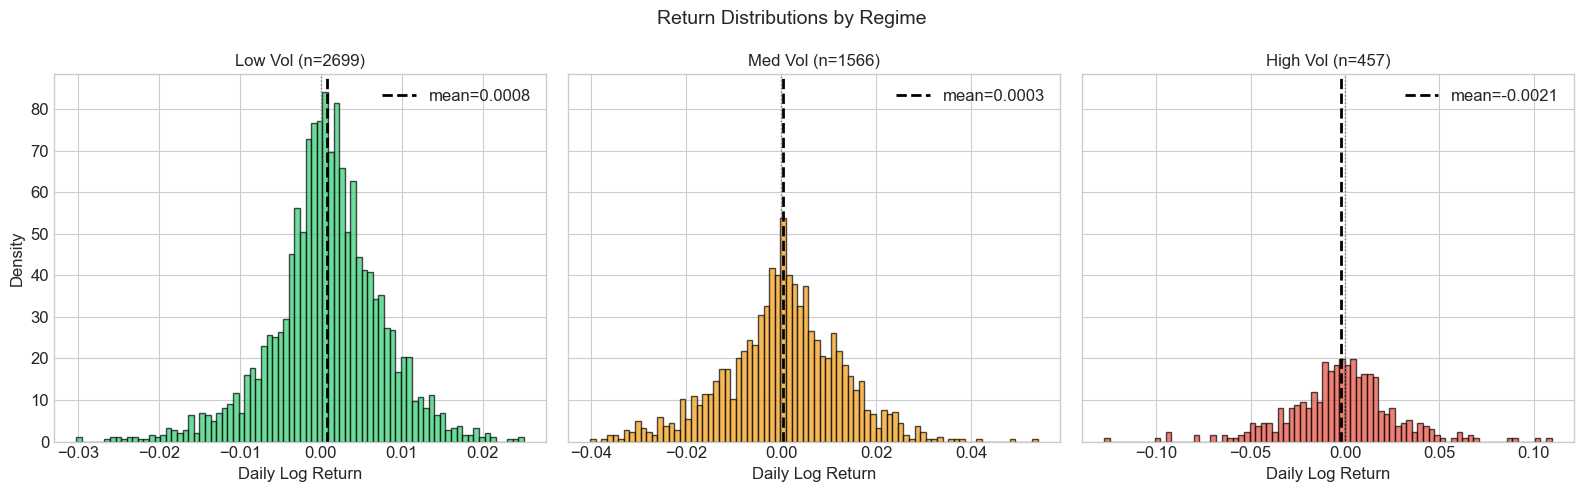

In [18]:
# Distribution of returns per regime
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
colors = ['#2ecc71', '#f39c12', '#e74c3c']

for r in [0, 1, 2]:
    sub = analysis[analysis['regime'] == r]['log_return']
    axes[r].hist(sub, bins=80, color=colors[r], edgecolor='black', alpha=0.7, density=True)
    axes[r].set_title(f'{regime_names[r]} (n={len(sub)})', fontsize=12)
    axes[r].set_xlabel('Daily Log Return')
    axes[r].axvline(sub.mean(), color='black', ls='--', lw=2, label=f'mean={sub.mean():.4f}')
    axes[r].axvline(0, color='gray', ls=':', lw=1)
    axes[r].legend()

axes[0].set_ylabel('Density')
fig.suptitle('Return Distributions by Regime', fontsize=14)
plt.tight_layout()
plt.show()

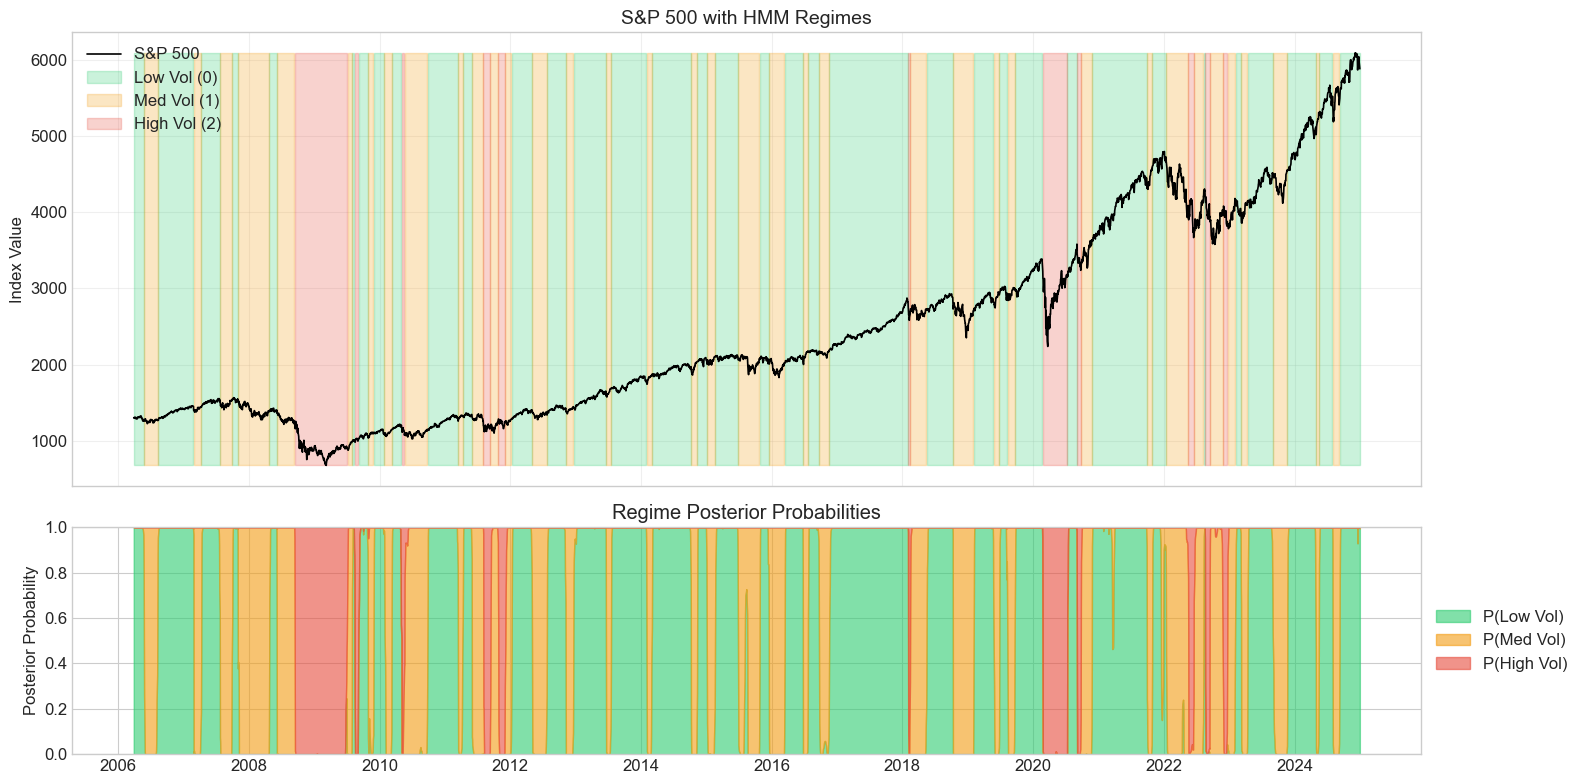

In [19]:
# Posterior probability timeline
proba = detector.predict_proba(features)

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True,
                          gridspec_kw={'height_ratios': [2, 1]})

# Price with regimes
plot_regimes(sp500, all_regimes, title='S&P 500 with HMM Regimes', ax=axes[0])

# Posterior probabilities
axes[1].fill_between(proba.index, 0, proba['p_low_vol'], color='#2ecc71', alpha=0.6, label='P(Low Vol)')
axes[1].fill_between(proba.index, proba['p_low_vol'], 
                     proba['p_low_vol'] + proba['p_med_vol'], 
                     color='#f39c12', alpha=0.6, label='P(Med Vol)')
axes[1].fill_between(proba.index, proba['p_low_vol'] + proba['p_med_vol'], 1, 
                     color='#e74c3c', alpha=0.6, label='P(High Vol)')
axes[1].set_ylabel('Posterior Probability')
axes[1].set_ylim(0, 1)
axes[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))
axes[1].set_title('Regime Posterior Probabilities')

plt.tight_layout()
plt.show()

## 7. Model Selection: Number of Regimes

Is 3 the right number? Let's check BIC/AIC for n=2,3,4,5.

In [22]:
# Compare different numbers of regimes using log-likelihood and BIC
results = []

for n in [2, 3, 4, 5]:
    try:
        det = RegimeDetector(n_regimes=n, n_iter=200, random_state=42)
        det.fit(train_features)
        
        train_ll = det.score(train_features)
        test_ll = det.score(test_features)
    except ValueError:
        # Full covariance can fail for higher n — fall back to diagonal
        det = RegimeDetector(n_regimes=n, covariance_type='diag', n_iter=200, random_state=42)
        det.fit(train_features)
        
        train_ll = det.score(train_features)
        test_ll = det.score(test_features)
        print(f'  n={n}: fell back to diagonal covariance')
    
    # BIC = -2*LL + k*ln(n_samples)  (lower is better)
    n_features = train_features.shape[1]
    if det.model.covariance_type == 'full':
        n_params = n * n_features + n * n_features * (n_features + 1) // 2 + (n * n - n)
    else:  # diag
        n_params = n * n_features + n * n_features + (n * n - n)
    bic = -2 * train_ll + n_params * np.log(len(train_features))
    aic = -2 * train_ll + 2 * n_params
    
    results.append({
        'n_regimes': n, 
        'train_LL': train_ll, 
        'test_LL': test_ll,
        'BIC': bic, 
        'AIC': aic,
        'n_params': n_params
    })

results_df = pd.DataFrame(results).set_index('n_regimes')
display(results_df.round(2))

best_bic = results_df['BIC'].idxmin()
best_test = results_df['test_LL'].idxmax()
print(f'\nBest by BIC:     {best_bic} regimes')
print(f'Best by test LL: {best_test} regimes')

Model is not converging.  Current: 36187.56625402952 is not greater than 36187.74063261984. Delta is -0.17437859031633707
Model is not converging.  Current: 36152.68214540315 is not greater than 36152.92529084851. Delta is -0.24314544535445748
Model is not converging.  Current: 35541.457705749446 is not greater than 35543.441829712625. Delta is -1.9841239631787175


  n=5: fell back to diagonal covariance


,train_LL,test_LL,BIC,AIC,n_params
n_regimes,,,,,
2,34986.97,12119.45,-69810.94,-69933.95,20
3,36187.22,12530.43,-72105.48,-72308.43,33
4,36152.10,12482.12,-71912.99,-72208.20,48
5,35539.24,12421.23,-70670.96,-70978.47,50



Best by BIC:     3 regimes
Best by test LL: 3 regimes


## 8. Interface for RL Agents

This is how the RL agent routing will work:

```python
from src.hmm import RegimeDetector, compute_hmm_features

# 1. Train the detector (once)
detector = RegimeDetector(n_regimes=3)
detector.fit(train_features)

# 2. At each timestep, get current regime
today_features = compute_hmm_features(prices_up_to_today).iloc[-1].values
regime = detector.predict_single(today_features)

# 3. Route to the correct RL agent
agents = {0: agent_low_vol, 1: agent_med_vol, 2: agent_high_vol}
action = agents[regime].predict(observation)
```

In [23]:
# Demo: predict_single interface (what the RL agent routing will call)
# Simulate getting today's features and predicting the regime

latest_features = features.iloc[-1].values
latest_regime = detector.predict_single(latest_features)

print(f'Latest date: {features.index[-1].date()}')
print(f'Features: {dict(zip(features.columns, latest_features.round(6)))}')
print(f'Predicted regime: {latest_regime} ({regime_names[latest_regime]})')
print()
print('→ This would route to the', regime_names[latest_regime], 'RL agent')

Latest date: 2024-12-31
Features: {'daily_log_return': np.float64(-0.004294), 'rolling_vol': np.float64(0.009247), 'ma_ratio': np.float64(1.015103)}
Predicted regime: 0 (Low Vol)

→ This would route to the Low Vol RL agent


In [24]:
# Posterior probabilities for latest observation
latest_proba = detector.predict_proba(features.tail(1))
print('Posterior probabilities for latest observation:')
for col in latest_proba.columns:
    print(f'  {col}: {latest_proba[col].values[0]:.4f}')

Posterior probabilities for latest observation:
  p_low_vol: 1.0000
  p_med_vol: 0.0000
  p_high_vol: 0.0000


## Summary

| Property | Value |
|----------|-------|
| Model | Gaussian HMM (hmmlearn) |
| States | 3 (low vol, med vol, high vol) |
| Features | daily log return, 20-day rolling vol, MA(20)/MA(60) |
| Covariance | Full |
| Training | EM algorithm, 200 max iterations |

**Key files:**
- `src/hmm.py` — `RegimeDetector` class + `compute_hmm_features()`
- `hmm_development.ipynb` — this notebook (training & analysis)

**Interface for RL agents:**
```python
regime = detector.predict_single(feature_vector)  # → 0, 1, or 2
```